# Interleaved Multimodal Data -- Quickstart

This notebook walks through the NeMo Curator interleaved multimodal pipeline:

1. **Read** a WebDataset tar shard (MINT-1T format) into row-wise `InterleavedBatch` tasks
2. **Inspect** the interleaved schema -- text, images, and metadata in position order
3. **Display** a sample as an interleaved document (text + inline images)
4. **Filter** by image aspect ratio
5. **Write** to Parquet

Each sample in MINT-1T is a JSON file paired with a multi-frame TIFF.
The reader extracts individual frames so each image row carries its own single-frame binary.

## Step 0 -- Get the data

Download a single MINT-1T PDF tar shard (~79 MB) from HuggingFace.
Set `MINT1T_TAR_PATH` env var to use a local copy instead.

In [21]:
import os
from pathlib import Path

from huggingface_hub import hf_hub_download

LOCAL_TAR = os.environ.get("MINT1T_TAR_PATH", "")

if not LOCAL_TAR or not Path(LOCAL_TAR).exists():
    print("Downloading MINT-1T sample shard from HuggingFace...")
    LOCAL_TAR = hf_hub_download(
        repo_id="mlfoundations/MINT-1T-PDF-CC-2024-18",
        filename="CC-MAIN-2024-18-shard-0/CC-MAIN-20240412101354-20240412131354-00000.tar",
        repo_type="dataset",
    )
    print(f"Downloaded to: {LOCAL_TAR}")
else:
    print(f"Using local: {LOCAL_TAR}")

Downloaded to: /raid/vjawa/hf_cache/hub/datasets--mlfoundations--MINT-1T-PDF-CC-2024-18/snapshots/089d3c500aded3a66f84d2ba05bddfd58e5ac8cc/CC-MAIN-2024-18-shard-0/CC-MAIN-20240412101354-20240412131354-00000.tar


## Step 1 -- Read a WebDataset tar shard

In [22]:
from nemo_curator.stages.interleaved.io.readers.webdataset import WebdatasetReaderStage
from nemo_curator.tasks import FileGroupTask

task = FileGroupTask(task_id="quickstart", dataset_name="mint1t", data=[LOCAL_TAR], _metadata={})
reader = WebdatasetReaderStage(
    source_id_field="pdf_name",
    materialize_on_read=True,
    per_image_fields=["image_metadata"],
)
result = reader.process(task)
batch = result[0] if isinstance(result, list) else result

print(f"Samples: {batch.num_items}")
print(f"Total rows: {batch.count()}")
print(f"  text:     {batch.count(modality='text')}")
print(f"  image:    {batch.count(modality='image')}")
print(f"  metadata: {batch.count(modality='metadata')}")

Samples: 56
Total rows: 526
  text:     228
  image:    242
  metadata: 56


## Step 2 -- Inspect the interleaved schema

Reserved columns managed by the pipeline, plus passthrough fields from the source JSON.

In [23]:
import json

import pandas as pd

df = batch.to_pandas()
print(f"All columns: {list(df.columns)}\n")

sample_id = df["sample_id"].iloc[0]
sample = df[df["sample_id"] == sample_id].sort_values("position")

MAX_LEN = 60


def _fmt(x: object, max_len: int = MAX_LEN) -> str | None:
    if pd.isna(x) or x is None:
        return None
    if isinstance(x, (bytes, bytearray)):
        return f"{len(x):,} bytes"
    s = str(x)
    return s[:max_len] + "..." if len(s) > max_len else s


def _fmt_source_ref(x: object) -> str | None:
    if pd.isna(x) or x is None:
        return None
    try:
        ref = json.loads(x)
        parts = []
        if ref.get("member"):
            parts.append(ref["member"])
        if ref.get("frame_index") is not None:
            parts.append(f"frame={ref['frame_index']}")
        if ref.get("byte_offset") is not None:
            parts.append(f"off={ref['byte_offset']}")
        return " | ".join(parts) if parts else "-"
    except (ValueError, TypeError):
        return _fmt(x)


show = sample.copy()
show["text_content"] = show["text_content"].map(_fmt)
show["binary_content"] = show["binary_content"].map(_fmt)
show["source_ref"] = show["source_ref"].map(_fmt_source_ref)
show["materialize_error"] = show["materialize_error"].map(_fmt)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 220)

print(f"Sample '{sample_id}' -- {len(sample)} rows\n")
show.reset_index(drop=True)

All columns: ['sample_id', 'position', 'modality', 'content_type', 'text_content', 'binary_content', 'source_ref', 'materialize_error', 'bff_contained_ngram_count_before_dedupe', 'language_id_whole_page_fasttext', 'previous_word_count', 'url', 'image_metadata']

Sample 'ba16decf89064be49237fb81a59fd3f3' -- 17 rows



,sample_id,position,modality,content_type,text_content,binary_content,source_ref,materialize_error,bff_contained_ngram_count_before_dedupe,language_id_whole_page_fasttext,previous_word_count,url,image_metadata
0,ba16decf89064be49237fb81a59fd3f3,-1,metadata,application/json,None,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,271,"{""en"": 0.8799859881401062}",7605,https://en.rli.nl/sites/default/files/advice_eletricity_provision_in_the_fac...,<NA>
1,ba16decf89064be49237fb81a59fd3f3,0,image,image/tiff,None,"339,769 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=0 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 862, ""page"": 0, ""sha256"": ""a58edd0a4c680551e13656c3a3ec3f36586c69..."
2,ba16decf89064be49237fb81a59fd3f3,1,text,text/plain,DIGITALISATION FEBRUARY 2018 About the Council for the Envir...,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,<NA>,<NA>,<NA>,<NA>,<NA>
3,ba16decf89064be49237fb81a59fd3f3,2,image,image/tiff,None,"411,857 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=1 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 861, ""page"": 4, ""sha256"": ""f7ad963489f3664cf86a9ffffeb3b3c6b66d0c..."
4,ba16decf89064be49237fb81a59fd3f3,3,text,text/plain,SUMMARY The Netherlands’ electricity system is increasingly ...,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,<NA>,<NA>,<NA>,<NA>,<NA>
5,ba16decf89064be49237fb81a59fd3f3,4,image,image/tiff,None,"382,287 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=2 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 1069, ""page"": 6, ""sha256"": ""e2b4360c458c97de96b0aa838ab8b0e6c2afe..."
6,ba16decf89064be49237fb81a59fd3f3,5,text,text/plain,INTRODUCTION 1.1 Context The reliability and continuity of e...,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,<NA>,<NA>,<NA>,<NA>,<NA>
7,ba16decf89064be49237fb81a59fd3f3,6,image,image/tiff,None,"327,493 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=3 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 1070, ""page"": 9, ""sha256"": ""a9e58a398eb10875c3c451150ae9091506117..."
8,ba16decf89064be49237fb81a59fd3f3,7,text,text/plain,ELECTRICITY SYSTEM The coming years will see far-reaching ch...,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,<NA>,<NA>,<NA>,<NA>,<NA>
9,ba16decf89064be49237fb81a59fd3f3,8,image,image/tiff,None,"61,401 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=4 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 391, ""page"": 11, ""sha256"": ""16e532341b76228bc4235545512973885295d..."


## Step 3 -- Display as an interleaved document

Render the first sample the way a human would read it: metadata at the top,
then text and images in position order. Each image is converted to PNG for
inline display (works on GitHub, JupyterLab, and VS Code).

### Sample `ba16decf89064be49237fb81a59fd3f3`

  url:   https://en.rli.nl/sites/default/files/advice_eletricity_provision_in_the_face_of_ongoing_digitalisation_rli_2018-01.pdf
  lang:  {"en": 0.8799859881401062}

[0] IMAGE  frame=0  1081x862  339,769 bytes  n_frames=1


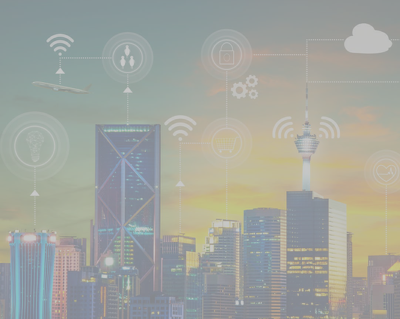


[1] TEXT: DIGITALISATION FEBRUARY 2018 About the Council for the Environment and Infrastructure The Council for the Environment and Infrastructure (Raad voor de leefomgeving en infrastructuur, Rli) advises the Dutch government and Parliament on strategic issues concerning the sustainable development of the li...

[2] IMAGE  frame=1  1070x861  411,857 bytes  n_frames=1


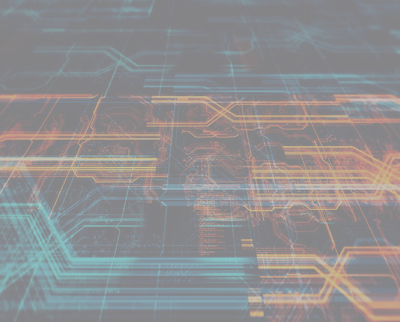


[3] TEXT: SUMMARY The Netherlands’ electricity system is increasingly reliant on digital technology. Important decisions concerning generation, transmission and distribution are now made with the help of advanced software and algorithms. This development is one feature of an electricity system which is changi...

[4] IMAGE  frame=2  861x1069  382,287 bytes  n_frames=1


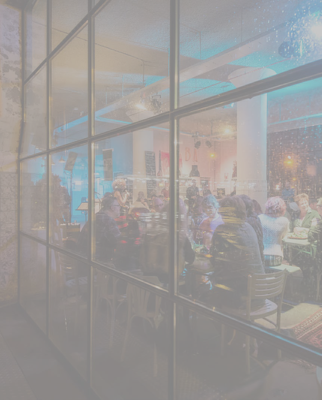


[5] TEXT: INTRODUCTION 1.1 Context The reliability and continuity of electricity provision is a matter of great importance. Any disruption has the potential to cause personal injury, physical damage and/or financial loss. A protracted power outage could lead to considerable public unrest and would therefore c...

[6] IMAGE  frame=3  861x1070  327,493 bytes  n_frames=1


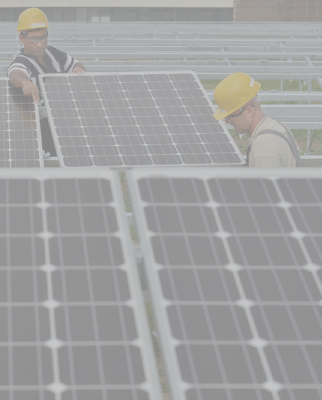


[7] TEXT: ELECTRICITY SYSTEM The coming years will see far-reaching changes to our electricity system as the result of a number of developments. In this section, the Council discusses four of those developments before examining the change which is central to this report: the digitalisation of the electricity ...

[8] IMAGE  frame=4  636x391  61,401 bytes  n_frames=1


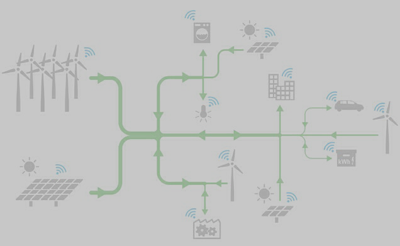


[9] TEXT: From centralised generation to digitalised, decentralised, local generation by utility companies, 
other private sector parties and private individuals; all components of the system must be able 
to communicate with each other. For example, digital technology will allow a rapid response to fluctuati...

[10] IMAGE  frame=5  494x546  63,629 bytes  n_frames=1


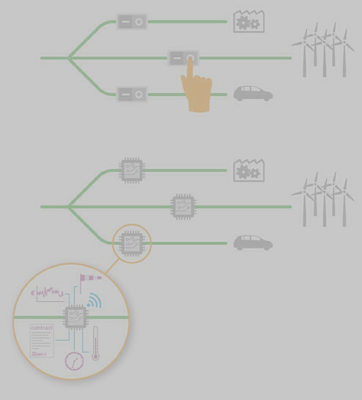


[11] TEXT: Figure 2. The difference between analogue and digital switching points Analogue switches are operated manually. Digital switching points control devices based on 
data such as the amount of electricity being generated and consumed, prices, consumption 
patterns and weather conditions. 3 NEW

[12] IMAGE  frame=6  861x1067  454,509 bytes  n_frames=1


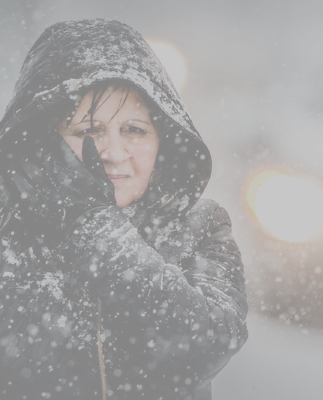


[13] TEXT: VULNERABILITIES The digitalisation of the electricity system creates new vulnerabilities in the electricity supply. There could be problems at various points: the equipment which remotely controls generation and storage requirements, the networks (grids), or the complex digital processes underlying ...

[14] IMAGE  frame=7  861x1067  342,095 bytes  n_frames=1


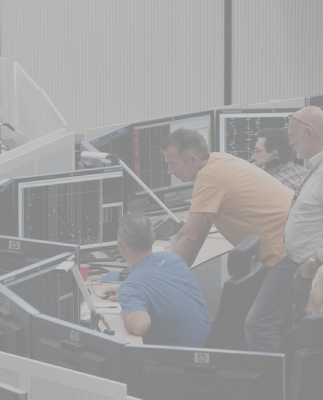


[15] TEXT: RECOMMENDATIONS The Netherlands occupies a good starting position with regard to the transformation of its electricity system. Our current electricity provision is marked by a high degree of reliability, and is achieved at relatively low it is not yet possible to carefully assess whether the instrum...



In [24]:
from io import BytesIO

from IPython.display import Image, Markdown
from IPython.display import display as ipy_display
from PIL import Image as PILImage

MAX_TEXT_DISPLAY = 300

meta_row = sample[sample["modality"] == "metadata"].iloc[0]

ipy_display(Markdown(f"### Sample `{sample_id}`"))
print(f"  url:   {meta_row.get('url', '-')}")
print(f"  lang:  {meta_row.get('language_id_whole_page_fasttext', '-')}")
print()

content = sample[sample["modality"] != "metadata"].sort_values("position")

for _, row in content.iterrows():
    pos = int(row["position"])
    mod = row["modality"]

    if mod == "text":
        text = str(row["text_content"]) if not pd.isna(row.get("text_content")) else ""
        snippet = text[:MAX_TEXT_DISPLAY] + "..." if len(text) > MAX_TEXT_DISPLAY else text
        print(f"[{pos}] TEXT: {snippet}")
        print()

    elif mod == "image":
        bc = row["binary_content"]
        if bc is not None and not pd.isna(bc):
            img = PILImage.open(BytesIO(bc))
            ref = json.loads(row["source_ref"]) if isinstance(row["source_ref"], str) else {}
            fi = ref.get("frame_index", "-")
            w, h = img.size
            print(f"[{pos}] IMAGE  frame={fi}  {w}x{h}  {len(bc):,} bytes  n_frames={img.n_frames}")
            thumb = img.copy()
            thumb.thumbnail((400, 400))
            buf = BytesIO()
            thumb.save(buf, format="PNG")
            ipy_display(Image(data=buf.getvalue(), format="png"))
            print()

## Step 4 -- Filter by aspect ratio

`InterleavedAspectRatioFilterStage` opens each image's binary content,
computes the aspect ratio, and drops rows outside the specified range.
Positions are automatically recomputed after filtering.

In [25]:
from nemo_curator.stages.interleaved.stages import InterleavedAspectRatioFilterStage

filter_stage = InterleavedAspectRatioFilterStage(
    min_aspect_ratio=0.5,
    max_aspect_ratio=2.0,
)
filtered_batch = filter_stage.process(batch)

print(f"Before: {batch.count()} rows  ({batch.count(modality='image')} images)")
print(f"After:  {filtered_batch.count()} rows  ({filtered_batch.count(modality='image')} images)")
print(f"Dropped {batch.count() - filtered_batch.count()} rows")

Before: 526 rows  (242 images)
After:  504 rows  (220 images)
Dropped 22 rows


## Step 5 -- Write to Parquet

The writer materializes any remaining lazy binary content and writes to Parquet.
The DataFrame index is never included in the output.

In [26]:
import tempfile

import pyarrow.parquet as pq

from nemo_curator.stages.interleaved.io.writers.tabular import InterleavedParquetWriterStage

output_dir = tempfile.mkdtemp(prefix="nemo_curator_quickstart_")

writer = InterleavedParquetWriterStage(
    path=output_dir,
    materialize_on_write=False,
    mode="overwrite",
)
write_result = writer.process(batch)
parquet_path = write_result.data[0]

schema = pq.read_schema(parquet_path)
roundtrip = pd.read_parquet(parquet_path)

print(f"Written to: {parquet_path}")
print(f"Columns: {schema.names}")
print(f"Rows: {len(roundtrip)}")
print(f"Images with binary: {roundtrip[roundtrip['modality'] == 'image']['binary_content'].notna().sum()}")

2026-03-03 22:09:56.516 | INFO     | nemo_curator.utils.file_utils:check_output_mode:335 - Removing output directory /raid/vjawa/tmp/tmp/nemo_curator_quickstart_omedp5ay for overwrite mode
2026-03-03 22:09:56.517 | WARNING  | nemo_curator.stages.interleaved.io.writers.base:process:102 - The task does not have source_files in metadata, using UUID for base filename


Written to: /raid/vjawa/tmp/tmp/nemo_curator_quickstart_omedp5ay/b6aeb6d3b5454c20850bfd58db7a28dc.parquet
Columns: ['sample_id', 'position', 'modality', 'content_type', 'text_content', 'binary_content', 'source_ref', 'materialize_error', 'bff_contained_ngram_count_before_dedupe', 'language_id_whole_page_fasttext', 'previous_word_count', 'url', 'image_metadata']
Rows: 526
Images with binary: 242


Roundtrip image: frame=0  635x458  n_frames=1


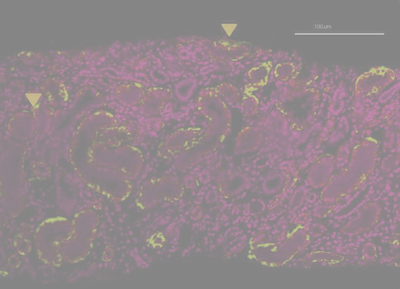

In [27]:
# Verify roundtrip -- display one image from the parquet output
rt_images = roundtrip[roundtrip["modality"] == "image"]
first_img = rt_images.iloc[10]
bc = first_img["binary_content"]
ref = json.loads(first_img["source_ref"]) if isinstance(first_img["source_ref"], str) else {}

img = PILImage.open(BytesIO(bc))
print(f"Roundtrip image: frame={ref.get('frame_index', '-')}  {img.size[0]}x{img.size[1]}  n_frames={img.n_frames}")

thumb = img.copy()
thumb.thumbnail((400, 400))
buf = BytesIO()
thumb.save(buf, format="PNG")
ipy_display(Image(data=buf.getvalue(), format="png"))